C:\Users\Omer\bbCodes
C:\Users\Omer\bbCodes\figures


Loading data set from C:\Users\Omer\bbCodes:   0%|          | 0/1 [00:00<?, ?it/s]

18402947 codes were loaded
18402947 codes were loaded


C:\Users\Omer\AppData\Local\Temp\ipykernel_26512\1257785129.py:232: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


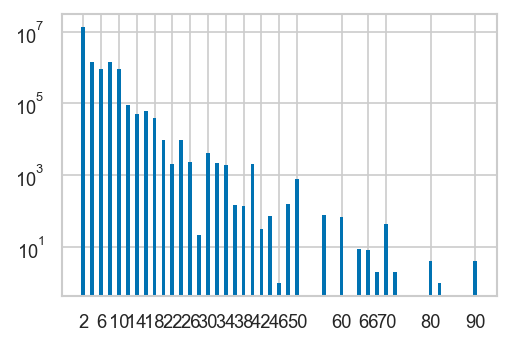

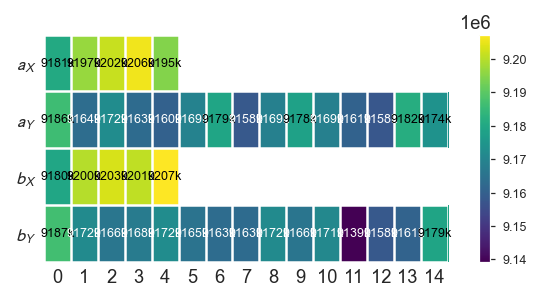

Loading data set from C:\Users\Omer\bbCodes:   0%|          | 0/1 [23:06<?, ?it/s]


MemoryError: Unable to allocate 4.11 GiB for an array with shape (2, 276044205) and data type float64

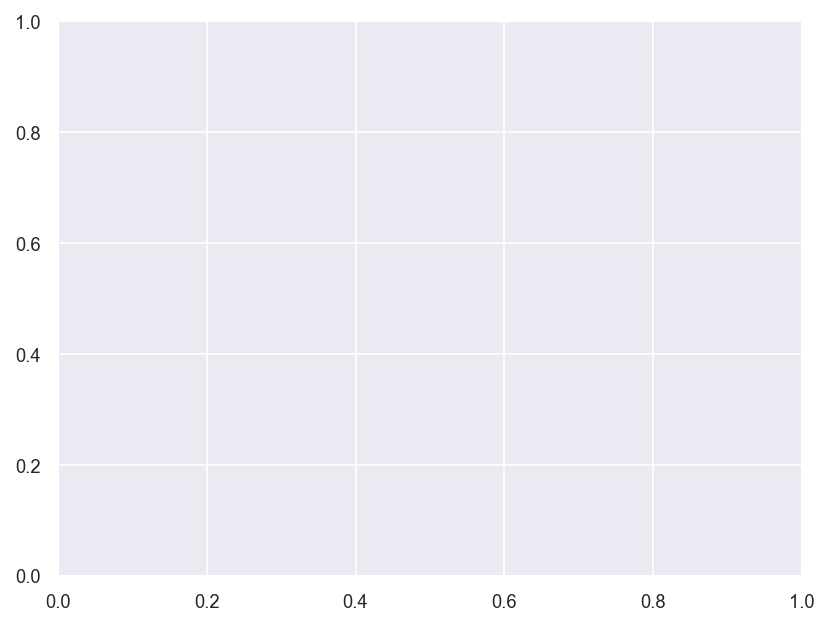

In [ ]:
"""
Scripts to 
1. Load data from the BB codes dataset.
2. Filter records according to code size and error range.
3. Plot figures.
4. Take over the world.

Warning: It takes around 2.5 hours to run ALL CODE SIZES, and when hitting the 5,15 records I ran out of memory (32GB laptop).
So i would advise the user to plot one code size at a time and restart the kernel to clear out memory.
Some runtime numbers:
(9,6), # 18 - 30 minutes on my laptop
(6,6), # ~14 minutes on my laptop
(12,6), # ~20 minutes on my laptop
(15,3), # ~25 minutes on my laptop
(21,18), # ~22 minutes on my laptop
(3,27), # ~23 minutes on my laptop
(5,15)) # ~minutes on my laptop
Alternatively, run this notebook on a machine that has more memory.

"""

import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import fnmatch
import json
from dataclasses import dataclass
from tqdm import tqdm


## Safety check - you MUST set two environmet variables, otherwise this workbook fails: 
## QECC_CODES_DATA - points to the place (path) where the dataset is
## QECC_CODES_FIGURES - points to where to save the figures generated in this workbook. You can 
if "QECC_CODES_DATA" not in os.environ:
    raise ValueError("You must set an environment variable QECC_CODES_DATA that will tell this workbook where to get the dataset from.")
print(os.environ.get("QECC_CODES_DATA"))
if "QECC_CODES_FIGURES" not in os.environ:
    raise ValueError("You must set an environment variable QECC_CODES_FIGURES that will tell this workbook where to save the figures.")
print(os.environ.get("QECC_CODES_FIGURES"))

### Constants relating to where to save figures, whether to generate figure titles and x_labels / y_lables
MAKE_FIGURES_FOR_PAPER = True #If you switch this to False the figures will be generated with titles, xlabels, ylabels. If True the figures are not annotated, because that's done in the paper.

SAVE_PATH = os.environ.get("QECC_CODES_FIGURES")
GRID_TOLERANCE = 1e-9


### Constants relating to which code sizes to plot, which error range to use
errorRangeName = "union"

# allSizes = ((9,6), # 18 - 30 minutes on my laptop
#             (6,6), # ~14 minutes on my laptop
#             (12,6), # ~20 minutes on my laptop
#             (15,3), # ~25 minutes on my laptop
#             (21,18), # ~22 minutes on my laptop
#             (3,27), # ~23 minutes on my laptop
#             (5,15)) # ~24 minutes on my laptop

sizesToProcess = ((5,15),)
############### Constants relating to error ranges, code baselines. If you have qecc installed, these are imported from qecc.utils, but to make the codes dataset standalone I placed them again here. It has some repitition repitition in it ...

GEOMETRIC5_ERROR_RANGE = np.geomspace(0.001, 0.1, 5)
CANONICAL_ERROR_RANGE = np.linspace(0.0001, 0.1, 5)
FIVE_POINT_GRID = np.linspace(1e-4, 1e-1, 5)
TEN_POINT_GRID = np.linspace(1e-4, 1e-1, 10)

LINEAR5 = np.linspace(0.0001,0.1,5)
GEOMETRIC5 = np.geomspace(0.001, 0.1, 5)
GEOMETRIC7 = np.geomspace(0.001, 0.1, 7)
GEOMETRIC10 = np.geomspace(0.0001, 0.1, 10)
# This (union) is the error range for most of the records. It has 15 error points.
UNION_ERROR_RANGE = np.unique(np.round(np.concatenate([
            np.linspace(0.0001, 0.1, 5),
            np.geomspace(0.001, 0.1, 5),
            np.geomspace(0.001, 0.1, 7),
            np.geomspace(0.0001, 0.1, 10)]), 10))

NAMED_ERROR_RANGES = {"linear5": CANONICAL_ERROR_RANGE, 
                      "geometric5": GEOMETRIC5_ERROR_RANGE, 
                      "dataCollection": UNION_ERROR_RANGE, 
                      "geometric7": GEOMETRIC7, 
                      "geometric10": GEOMETRIC10, 
                      "union" : UNION_ERROR_RANGE}


# baseline codes from the paper. 
baselines = {(6,6): {"name": "[[72,12,6]]", "reward": 0.035964,"number of logical qubits": 12, "reward_geometric5": 0.3460, "reward_linear5":0.3600},#0.033189,
             (9,6): {"name": "[[108,8,10]]", "reward": 0.0374625,"number of logical qubits": 8, "reward_geometric5": 0.5455, "reward_linear5":0.375},#0.040959,
             (15,3): {"name": "[[90,8,10]]", "reward":0.035964,"number of logical qubits": 8, "reward_geometric5": 0.5063, "reward_linear5":0.3600}, #0.04218,
             (12,6): {"name": "[[144,12,12]]", "reward":0.037462499999999996,"number of logical qubits": 12, "reward_geometric5": 0.554, "reward_linear5":0.3749},# 0.038739,
#             (12,12): {"reward":0.041958,"number of logical qubits": 12, "reward_geometric5": 0.60, "reward_linear5":0.385}, #TODO: add code name and double check reward value0.0414,
             (21,18): {"name": "[[756,16,≤34]]", "reward":0.0384615,"number of logical qubits": 16, "reward_geometric5": 0.60, "reward_linear5":0.385}, #TODO: double check reward value
             (3,27): {"number of logical qubits": None,},#TODO: add name and double check reward value
             (5,15): {"number of logical qubits": None,},#TODO: add name and double check reward value
             (30,6): {"name": "[[360,12,≤24]]", "number of logical qubits": 12,},
             (12,12): {"name": "[[288,12,18]]","number of logical qubits": 12,}
             }





@dataclass
class CodeEvaluationData:
    bits: np.ndarray      # (N, 2l+2m) int8, order [aX | aY | bX | bY]
    counts: np.ndarray    # (N, 5) int64, combined logical + decoder-failure counts
    samples: np.ndarray   # (N,) int64, total Bernoulli trials (post-dedup)
    k: np.ndarray         # (N,) int64, numberOfLogicalQubits
    l: int
    m: int


def iterRecords(rootDirectory):
    """ 
    Go over the records, strip them. and tolerate broken lines 
    """
    for dirpath, _dirnames, filenames in os.walk(rootDirectory):
        for name in fnmatch.filter(filenames, "codeEvaluations_*.jsonl"):
            with open(os.path.join(dirpath, name)) as fid:
                for line in fid:
                    line = line.strip()
                    if not line:
                        continue
                    try:
                        yield json.loads(line)
                    except json.JSONDecodeError:
                        continue  


def gridProjection(recordGrid, errorRange, tolerance=GRID_TOLERANCE):
    """
    The original dataset has a mix of records, some sampled over a linear 5 points error range, some over geometric.
    Most records have an error range which is the union of several error ranges.
    What this function does is filter out / reduces / projects a record's error range to the erroRange passed to this function, withing the tolerance.
    """
    columns = []
    for point in errorRange:
        hits = np.flatnonzero(np.isclose(recordGrid, point, rtol=0, atol=tolerance))
        if hits.size != 1:
            return None
        columns.append(int(hits[0]))
    return columns

def loadCodeEvaluations(rootDirectory, l, m, errorRange):
    """Load, records, filter them to just (l, m) codes and the specified errorRange, dedup by summing counts."""
    aggregated = {}  
    dropped = 0
    projections = {}
    for record in iterRecords(rootDirectory):
        if record["l"] != l or record["m"] != m:
            continue
        recordGrid = np.asarray(record["errorRange"], dtype=float)

        gridKey = recordGrid.tobytes() # We're checking if the error range (grid) in the record has already been parsed in some past record. If yes, we use the projection already computed. If no, we calculate a projection
        if gridKey not in projections:
            projections[gridKey] = gridProjection(recordGrid, errorRange)
        columns = projections[gridKey]
        if columns is None:
            dropped += 1
            continue
        combined = (np.asarray(record["logicalErrorCounts"], dtype=np.int64)[columns] +
                    np.asarray(record["decoderFailureCounts"], dtype=np.int64)[columns])

        
        bits = tuple(record["aX"]) + tuple(record["aY"]) + tuple(record["bX"]) + tuple(record["bY"]) 
        entry = aggregated.get(bits)
        if entry is None:
            aggregated[bits] = [combined,
                                int(record["numberOfSamples"]),
                                int(record["numberOfLogicalQubits"])]
        else:
            entry[0] = entry[0] + combined
            entry[1] = entry[1] + int(record["numberOfSamples"])
    if dropped:
        print(f"loadCodeEvaluations: kept {len(aggregated)} codes on the requested error range {errorRange}.\n Dropped {dropped} records whose grid does not contain all its points")
    if not aggregated:
        raise ValueError(f"No records found for l={l}, m={m} under {rootDirectory}")
    bitsArray = np.array(list(aggregated.keys()), dtype=np.int8)
    countsArray = np.stack([entry[0] for entry in aggregated.values()])
    samplesArray = np.array([entry[1] for entry in aggregated.values()], dtype=np.int64)
    kArray = np.array([entry[2] for entry in aggregated.values()], dtype=np.int64)
    return CodeEvaluationData(bitsArray, countsArray, samplesArray, kArray, l, m)


def subset(data, indices):
    return CodeEvaluationData(data.bits[indices], data.counts[indices],
                              data.samples[indices], data.k[indices], data.l, data.m)


def splitData(data, fractions=(0.8, 0.1, 0.1), seed=0):
    assert abs(sum(fractions) - 1.0) < 1e-9, "fractions must sum to 1"
    n = data.bits.shape[0]
    permutation = np.random.default_rng(seed).permutation(n)
    trainEnd = int(round(fractions[0] * n))
    valEnd = trainEnd + int(round(fractions[1] * n))
    return (subset(data, permutation[:trainEnd]),
            subset(data, permutation[trainEnd:valEnd]),
            subset(data, permutation[valEnd:]))


plt.rcParams.update({                              
        "font.family": "Arial", "font.size": 7, "axes.labelsize": 7,
        "axes.titlesize": 7, "xtick.labelsize": 6.5, "ytick.labelsize": 6.5,
        "legend.fontsize": 6.5, "legend.frameon": False,
        "grid.linewidth": 0.6,
        "pdf.fonttype": 42, "mathtext.fontset": "stixsans",
        "figure.dpi": 150,
    })

dataPath = os.environ.get("QECC_CODES_DATA")
for l,m in tqdm(sizesToProcess, f"Loading data set from {dataPath}"):    
    errorRange = NAMED_ERROR_RANGES[errorRangeName]
    codes = loadCodeEvaluations(dataPath, l, m, errorRange=errorRange)
    print(f"{codes.bits.shape[0]} codes were loaded")
    # Plot the distribution of number of logical qubits
    print(f"{codes.bits.shape[0]} codes were loaded")
    sns.set_theme(style="whitegrid", context="paper")
    kValues, kCounts = np.unique(codes.k, return_counts=True)
    fig, ax = plt.subplots(figsize=(3.5, 2.4), constrained_layout=True)
    ax.bar(kValues, kCounts, width=0.85, color="#0072B2", lw=0)
    ax.set_yscale("log")
    ax.set_xticks(kValues[::2])
    if (l,m) in baselines.keys():
        if baselines[(l,m)]["number of logical qubits"] is not None:
            ax.axvline(x=baselines[(l,m)]["number of logical qubits"], color="0.2", linestyle="--", linewidth=0.8, dashes=(4,2), alpha=0.8)
            ax.text(baselines[(l,m)]["number of logical qubits"] + 1.0, 0.85, f"{l},{m} baseline", 
                    rotation=0, ha="left", va="bottom", transform=ax.get_xaxis_transform())
    if not MAKE_FIGURES_FOR_PAPER:
        plt.title(f'k distribution, l={l}, m={m} ({codes.k.shape[0]:,} codes)')
    fig.tight_layout()
    fig.savefig(os.path.join(SAVE_PATH, f"kDistribution_l_{l}_m_{m}.png"),  dpi=600)
    plt.show()

    # Plot the per polynomial coefficient hit count
    sns.set_theme(style="darkgrid", context="paper") 
    hits = codes.bits.astype(np.int64).sum(axis=0)   # use np.int64, to make sure there is no overflow 
    segments = [("$a_X$", l), ("$a_Y$", m), ("$b_X$", l), ("$b_Y$", m)]
    width = max(l, m)
    grid = np.full((4, width), np.nan)
    start = 0
    for row, (name, n) in enumerate(segments):
        grid[row, :n] = hits[start:start + n]
        start += n
    cmap = plt.get_cmap("viridis").copy()   # copy the color map to a local copy
    cmap.set_bad(color="white") # Fix it so bad / non existent coefficients correspond to a white background.

    fig, ax = plt.subplots(figsize=(3.5, 1.9), constrained_layout=True)
    im = ax.imshow(grid, cmap=cmap, aspect="auto")
    threshold = (np.nanmin(grid) + np.nanmax(grid)) / 2
    for r in range(4):
        for c in range(width):
            if np.isfinite(grid[r, c]):
                ax.text(c, r, f"{grid[r, c]/1000:.0f}k", ha="center", va="center",
                        fontsize=6, color="white" if grid[r, c] < threshold else "black")
                
    ax.set_xticks(range(width))
    ax.set_yticks(range(4), [name for name, _ in segments])
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)  # This is needed to avoid centre of cell white grid
    ax.set_xticks(np.arange(-0.5, width, 1), minor=True)  # This is needed to make minor ticks at the cell edges
    ax.set_yticks(np.arange(-0.5, 4, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.2)
    ax.tick_params(which="minor", length=0)
    cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cb.ax.tick_params(labelsize=6, width=0.6, length=2.5)
    cb.outline.set_linewidth(0.6)
    if not MAKE_FIGURES_FOR_PAPER:
        ax.set_title(f'coefficient usage across {codes.bits.shape[0]:,} codes (l={l}, m={m})') # Title, I diabled this for the paper
    fig.savefig(os.path.join(SAVE_PATH, f"coefficientUsage_l_{l}_m_{m}_error_range_{errorRangeName}.png"), dpi = 600)
    plt.show()

    sns.set_theme(style="darkgrid", context="paper")
    df = pd.DataFrame()
    rate = codes.counts / codes.samples[:,None]
    nCodes, nPoints = rate.shape
    df = pd.DataFrame({
        "errorRate": rate.ravel(),                  # row-major: code0's points, then code1's, ...
        "errorRange": np.tile(errorRange, nCodes),  # repeats [e0..en] per code, matches ravel order
        "k": np.repeat(codes.k, nPoints),            # repeats each k across its nPoints rows
    })
    df.keys()
    fig, ax = plt.subplots()
    sns.lineplot(data=df, x="errorRange", y="errorRate", estimator="mean", marker = "D", markersize = 5,
                errorbar=("pi", 100), color="#0072B2", err_kws={"alpha": 0.15}, ax=ax)
    sns.lineplot(data=df, x="errorRange", y="errorRate", estimator="mean", marker = "D", markersize = 5,
                errorbar=("pi", 95), color="#0072B2", err_kws={"alpha": 0.35}, ax=ax)
    ax.set_xscale("log")
    if MAKE_FIGURES_FOR_PAPER:
        ax.set_xlabel(None)
        ax.set_ylabel(None)
    else:
        ax.set_title(f"Logical error rate as a function of physical error rate for the entire pool of {codes.counts.shape[0]} with parameters l={l} m={m} ")
        ax.set_xlabel(f"Physical error rate")
        ax.set_ylabel(f"Logical error rate")
        ax.set_xticks(errorRange, labels=[f"{p:.3g}" for p in errorRange])
    ax.minorticks_off()
    #plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    fig.tight_layout()
    fig.savefig(os.path.join(SAVE_PATH, f"per_qer_l_{l}_m_{m}_error_range_{errorRangeName}.png"), dpi = 200)    